In [1]:
!pip install diffusers transformers accelerate safetensors torch --quiet


In [2]:
import torch
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt


c:\Users\hp\.anaconda\conda\Lib\site-packages\diffusers\models\transformers\transformer_kandinsky.py:168: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)
c:\Users\hp\.anaconda\conda\Lib\site-packages\diffusers\models\transformers\transformer_kandinsky.py:272: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cpu


In [4]:
model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32
)

pipe = pipe.to(device)

print("✅ Stable Diffusion model loaded!")


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: C:\Users\hp\.cache\huggingface\hub\models--runwayml--stable-diffusion-v1-5\snapshots\451f4fe16113bff5a5d2269ed5ad43b0592e9a14\safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: C:\Users\hp\.cache\huggingface\hub\models--runwayml--stable-diffusion-v1-5\snapshots\451f4fe16113bff5a5d2269ed5ad43b0592e9a14\text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Stable Diffusion model loaded!


  0%|          | 0/30 [00:00<?, ?it/s]

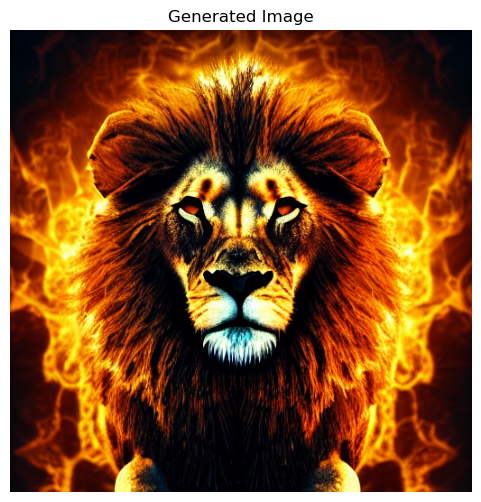

In [5]:
prompt = "A majestic lion made of fire, cinematic lighting, ultra detailed, 4k"

image = pipe(prompt, num_inference_steps=30).images[0]

plt.figure(figsize=(6,6))
plt.imshow(image)
plt.axis("off")
plt.title("Generated Image")
plt.show()


  0%|          | 0/30 [00:00<?, ?it/s]

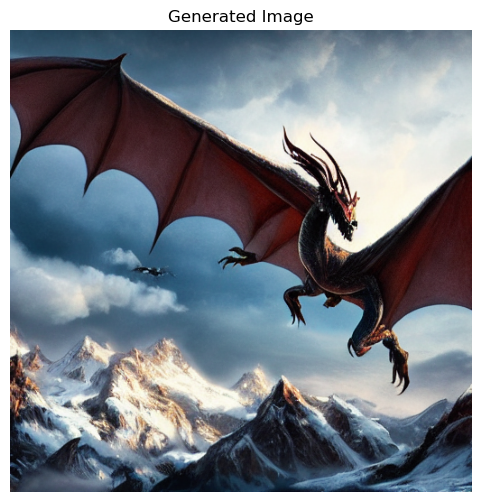

In [12]:
prompt = "A giant mythical dragon flying over snowy mountains, dramatic sky, cinematic lighting, ultra detailed fantasy art, 8k, epic scene"

image = pipe(prompt, num_inference_steps=30).images[0]

plt.figure(figsize=(6,6))
plt.imshow(image)
plt.axis("off")
plt.title("Generated Image")
plt.show()


In [13]:
image.save("stable_diffusion_output.png")
print("✅ Image saved as stable_diffusion_output.png")

✅ Image saved as stable_diffusion_output.png


In [10]:
prompts = [
    "A futuristic cyberpunk city at night, neon lights, highly detailed",
    "A fantasy castle floating in the sky, magical clouds, cinematic view",
    "An astronaut riding a horse on Mars, realistic, 4k"
]

for i, p in enumerate(prompts, start=1):
    img = pipe(p, num_inference_steps=30).images[0]
    img.save(f"output_{i}.png")
    print(f"✅ Saved output_{i}.png for prompt: {p}")


  0%|          | 0/30 [00:00<?, ?it/s]

✅ Saved output_1.png for prompt: A futuristic cyberpunk city at night, neon lights, highly detailed


  0%|          | 0/30 [00:00<?, ?it/s]

✅ Saved output_2.png for prompt: A fantasy castle floating in the sky, magical clouds, cinematic view


  0%|          | 0/30 [00:00<?, ?it/s]

✅ Saved output_3.png for prompt: An astronaut riding a horse on Mars, realistic, 4k
